In [3]:
import oracledb
conn = oracledb.connect('python/1234@localhost:1521/xe')

cursor = conn.cursor()
cursor.execute('select * from ontime where rownum <= 5')
rows = cursor.fetchall()
for row in rows:
    print(row)
    

(2006, 1, 11, 3, '743', 740, '1008', 1020, 'US', '754', 'N620AW', '205', '220', '176', '-12', '3', 'MSP', 'PHX', '1276', '5', '24', '0', None, '0', '0', '0', '0', '0', '0')
(2006, 1, 11, 3, '1343', 1350, '1618', 1630, 'US', '438', 'N768UW', '95', '100', '86', '-12', '-7', 'MSY', 'CLT', '651', '3', '6', '0', None, '0', '0', '0', '0', '0', '0')
(2006, 1, 11, 3, '1622', 1545, '1858', 1825, 'US', '1244', 'N756UW', '96', '100', '84', '33', '37', 'MSY', 'CLT', '651', '5', '7', '0', None, '0', '0', '0', '0', '0', '33')
(2006, 1, 11, 3, '1653', 1700, '2000', 2013, 'US', '566', 'N700UW', '127', '133', '117', '-13', '-7', 'MSY', 'DCA', '969', '3', '7', '0', None, '0', '0', '0', '0', '0', '0')
(2006, 1, 11, 3, '1034', 1040, '1413', 1413, 'US', '424', 'N724UW', '159', '153', '132', '0', '-6', 'MSY', 'PHL', '1088', '5', '22', '0', None, '0', '0', '0', '0', '0', '0')


In [8]:
cursor.execute('''select uniquecarrier, avg(depdelay)
               from ontime
               group by uniquecarrier''')
rows=cursor.fetchall()
for row in rows:
    print('{}\t{}'.format(row[0],row[1]))


US	7.804357385647844
WN	10.210241594584293
YV	13.802634169390085
OH	9.151028950122079
OO	8.62883295111009
XE	9.675919088499786
TZ	12.711202938475665
UA	11.663221388457785
DL	7.982176942258826
EV	16.005059620784717
F9	5.0310708464088885
FL	10.882964085084895
HA	-1.2108370229812355
MQ	11.04393478861564
NW	6.941889207170578
AA	10.529747652645987
AS	9.244730370630599
B6	11.24612154213649
CO	10.96718370724234
AQ	-0.11043603583236782


In [14]:
import oracledb
conn = oracledb.connect('python/1234@localhost:1521/xe')

cursor = conn.cursor()
cursor.execute('''select month, count(*) from ontime
               where arrdelay<>'NA' and arrdelay > 0
               group by month''')
rows = cursor.fetchall()
for row in rows:
    print(row)

(1, 233144)
(2, 233511)
(3, 272779)
(4, 250085)
(5, 257031)
(6, 287818)
(7, 289819)
(8, 277218)
(9, 254851)
(10, 296026)
(11, 257571)
(12, 287513)


In [ ]:
x = list(range(1,13))
y = []
for row in rows:
    y.append(row[1])
print(x)
print(y)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
[233144, 233511, 272779, 250085, 257031, 287818, 289819, 277218, 254851, 296026, 257571, 287513]


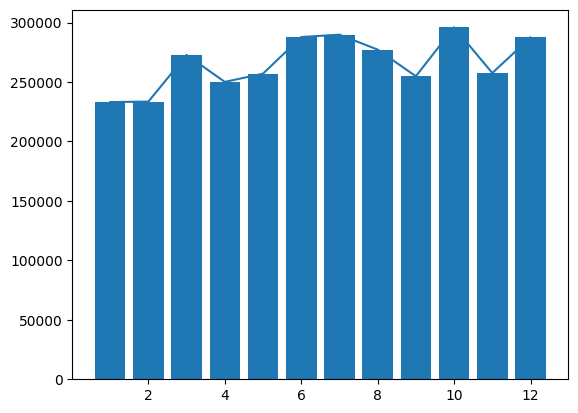

In [17]:
import matplotlib.pyplot as plt
plt.plot(x,y)
plt.bar(x,y)
plt.show()

In [19]:
cursor.execute('''select dayofweek, avg(arrdelay)
               from ontime
               where arrdelay<>'NA'
               group by dayofweek
               order by dayofweek''')
rows = cursor.fetchall()
for row in rows:
    print(row)

(1, 8.67324011930683)
(2, 6.087899705140723)
(3, 7.81942505503609)
(4, 11.305773593972738)
(5, 12.039587130869974)
(6, 5.093732178212869)
(7, 7.995601616596211)


In [21]:
x=['일','월','화','수','목','금','토']
y=[]
for row in rows:
    y.append(row[1])
print(x)
print(y)

['일', '월', '화', '수', '목', '금', '토']
[8.67324011930683, 6.087899705140723, 7.81942505503609, 11.305773593972738, 12.039587130869974, 5.093732178212869, 7.995601616596211]


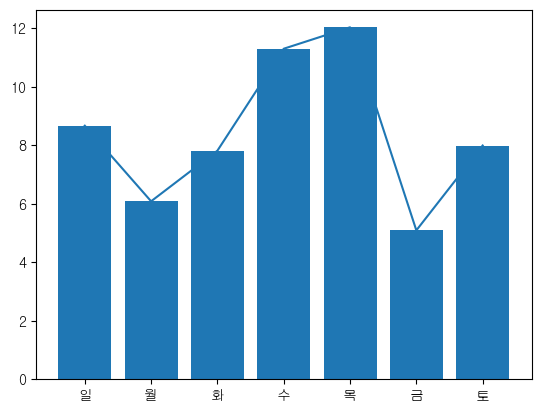

In [22]:
import matplotlib.pyplot as plt
from matplotlib import rc,font_manager
font_name=font_manager.FontProperties(fname='c:/windows/fonts/gulim.ttc').get_name()
rc('font',family=font_name)
plt.plot(x,y)
plt.bar(x,y)
plt.show()

In [23]:
cursor.execute('''select * from(
               select rownum as rn, A.*
               from(
               select CRSDepTime, avg(arrdelay) arrdelay
               from ontime
               where month=10 and dayofweek=1
               group by CRSDepTime
               order by arrdelay)A
               )where rn between 1 and 5''')
rows=cursor.fetchall()
for row in rows:
    print(row)

(1, 400, -24.75)
(2, 504, -21)
(3, 105, -20.125)
(4, 537, -19.11111111111111)
(5, 2238, -18)
